Imports

In [3]:
# ── CELL 1: Imports ─────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("✅ Libraries imported")

✅ Libraries imported


 Load Dataset

In [4]:
# ── CELL 2: Load Dataset ─────────────────────────────────────────────────────
from google.colab import files
import io

uploaded = files.upload()
filename = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[filename]), encoding="latin-1", on_bad_lines="skip")

print("✅ Loaded:", filename)
print("Shape:", df.shape)
df.head()

Saving aqi_data.csv to aqi_data.csv
✅ Loaded: aqi_data.csv
Shape: (420768, 17)


,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,2013,3,1,0,4.0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Aotizhongxin
1,2013,3,1,1,8.0,8.0,4.0,7.0,300.0,77.0,-1.1,1023.2,-18.2,0.0,N,4.7,Aotizhongxin
2,2013,3,1,2,7.0,7.0,5.0,10.0,300.0,73.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Aotizhongxin
3,2013,3,1,3,6.0,6.0,11.0,11.0,300.0,72.0,-1.4,1024.5,-19.4,0.0,NW,3.1,Aotizhongxin
4,2013,3,1,4,3.0,3.0,12.0,12.0,300.0,72.0,-2.0,1025.2,-19.5,0.0,N,2.0,Aotizhongxin


Drop Irrelevant Columns

In [5]:
# ── CELL 3: Drop Irrelevant Columns ─────────────────────────────────────────
# Drop: No (row id), year/month/day/hour (not useful for regression),
# wd (wind direction - categorical, skip for now), station (categorical)
cols_to_drop = ["No", "year", "month", "day", "hour", "wd", "station"]
cols_to_drop = [c for c in cols_to_drop if c in df.columns]
df.drop(columns=cols_to_drop, inplace=True)

print("Remaining columns:", df.columns.tolist())

Remaining columns: ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM']


 Missing Values Heatmap

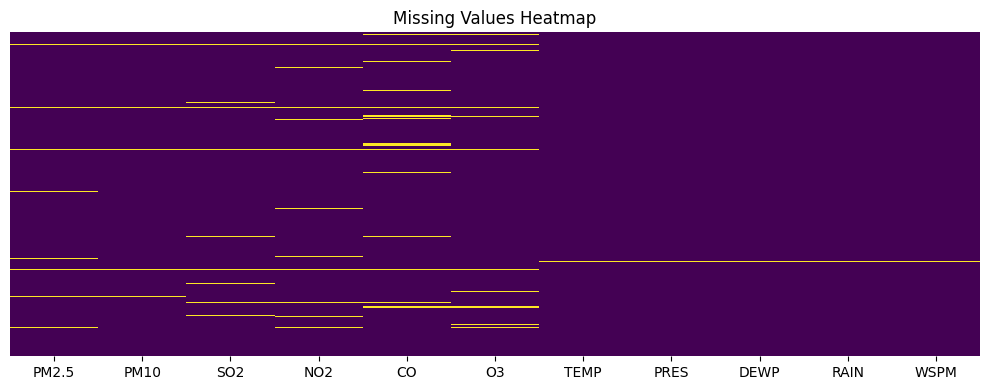


Missing value counts:
 PM2.5     8739
PM10      6449
SO2       9021
NO2      12116
CO       20701
O3       13277
TEMP       398
PRES       393
DEWP       403
RAIN       390
WSPM       318
dtype: int64

Total rows: 420768


In [6]:
# ── CELL 4: Missing Values Heatmap ──────────────────────────────────────────
plt.figure(figsize=(10, 4))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap="viridis")
plt.title("Missing Values Heatmap")
plt.tight_layout()
plt.show()

print("\nMissing value counts:\n", df.isnull().sum())
print(f"\nTotal rows: {len(df)}")

Diagnose Missing Values

In [7]:
# ── CELL 5a: Diagnose Missing Values ────────────────────────────────────────
from scipy.stats import skew

missing     = df.isnull().sum()
missing_pct = (missing / len(df)) * 100

diagnosis = pd.DataFrame({
    "Missing Count": missing,
    "Missing %": missing_pct.round(2)
})
print(diagnosis[diagnosis["Missing Count"] > 0])

       Missing Count  Missing %
PM2.5           8739       2.08
PM10            6449       1.53
SO2             9021       2.14
NO2            12116       2.88
CO             20701       4.92
O3             13277       3.16
TEMP             398       0.09
PRES             393       0.09
DEWP             403       0.10
RAIN             390       0.09
WSPM             318       0.08


 Impute Missing Values

In [8]:
# ── CELL 5b: Impute Missing Values ──────────────────────────────────────────
df_work = df.copy()

# Target: drop rows where PM2.5 is missing
before = len(df_work)
df_work = df_work[df_work["PM2.5"].notna()].copy()
print(f"Dropped {before - len(df_work)} rows where PM2.5 was missing.\n")

# Features: impute based on skew and missing %
feature_cols = ["PM10", "SO2", "NO2", "CO", "O3", "TEMP", "PRES", "DEWP", "RAIN", "WSPM"]

for col in feature_cols:
    if col not in df_work.columns:
        continue
    missing_pct = df_work[col].isnull().mean() * 100
    if missing_pct == 0:
        print(f"{col:>6}: no imputation needed")
        continue
    col_skew = skew(df_work[col].dropna())
    if missing_pct > 30:
        df_work[col] = df_work[col].fillna(df_work[col].median())
        print(f"{col:>6}: MEDIAN (high missingness: {missing_pct:.1f}%)")
    elif abs(col_skew) > 1:
        df_work[col] = df_work[col].fillna(df_work[col].median())
        print(f"{col:>6}: MEDIAN (skewed={col_skew:.2f}, missing={missing_pct:.1f}%)")
    else:
        df_work[col] = df_work[col].fillna(df_work[col].mean())
        print(f"{col:>6}: MEAN (skew={col_skew:.2f}, missing={missing_pct:.1f}%)")

print(f"\n✅ Shape after imputation: {df_work.shape}")
print(f"Remaining nulls:\n{df_work.isnull().sum()}")

Dropped 8739 rows where PM2.5 was missing.

  PM10: MEDIAN (skewed=1.88, missing=0.1%)
   SO2: MEDIAN (skewed=2.96, missing=0.9%)
   NO2: MEDIAN (skewed=1.05, missing=1.6%)
    CO: MEDIAN (skewed=2.56, missing=3.7%)
    O3: MEDIAN (skewed=1.67, missing=2.0%)
  TEMP: MEAN (skew=-0.10, missing=0.1%)
  PRES: MEAN (skew=0.10, missing=0.1%)
  DEWP: MEAN (skew=-0.19, missing=0.1%)
  RAIN: MEDIAN (skewed=30.29, missing=0.1%)
  WSPM: MEDIAN (skewed=1.63, missing=0.1%)

✅ Shape after imputation: (412029, 11)
Remaining nulls:
PM2.5    0
PM10     0
SO2      0
NO2      0
CO       0
O3       0
TEMP     0
PRES     0
DEWP     0
RAIN     0
WSPM     0
dtype: int64


Define Features & Target

In [9]:
# ── CELL 5c: Define Features & Target ───────────────────────────────────────
features = ["PM10", "SO2", "NO2", "CO", "O3", "TEMP", "PRES", "DEWP", "RAIN", "WSPM"]
features = [f for f in features if f in df_work.columns]
target   = "PM2.5"

X = df_work[features].copy()
y = df_work[target].copy()

print("Features:", features)
print("X shape :", X.shape)
print("y shape :", y.shape)

Features: ['PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM']
X shape : (412029, 10)
y shape : (412029,)


 Correlation Heatmap

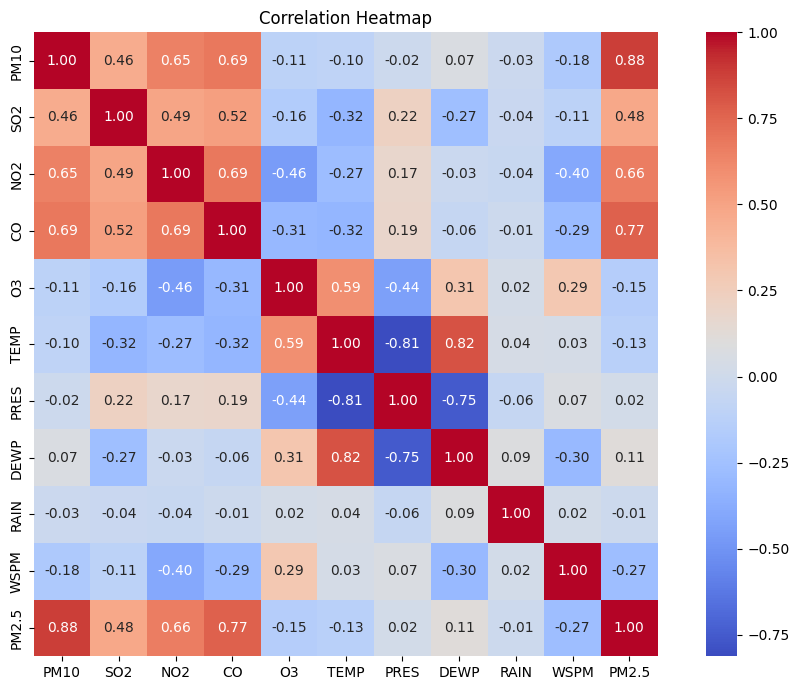

In [10]:
# ── CELL 6: Correlation Heatmap ─────────────────────────────────────────────
corr = df_work[features + [target]].corr()

plt.figure(figsize=(10, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

Box Plots Before Outlier Handling

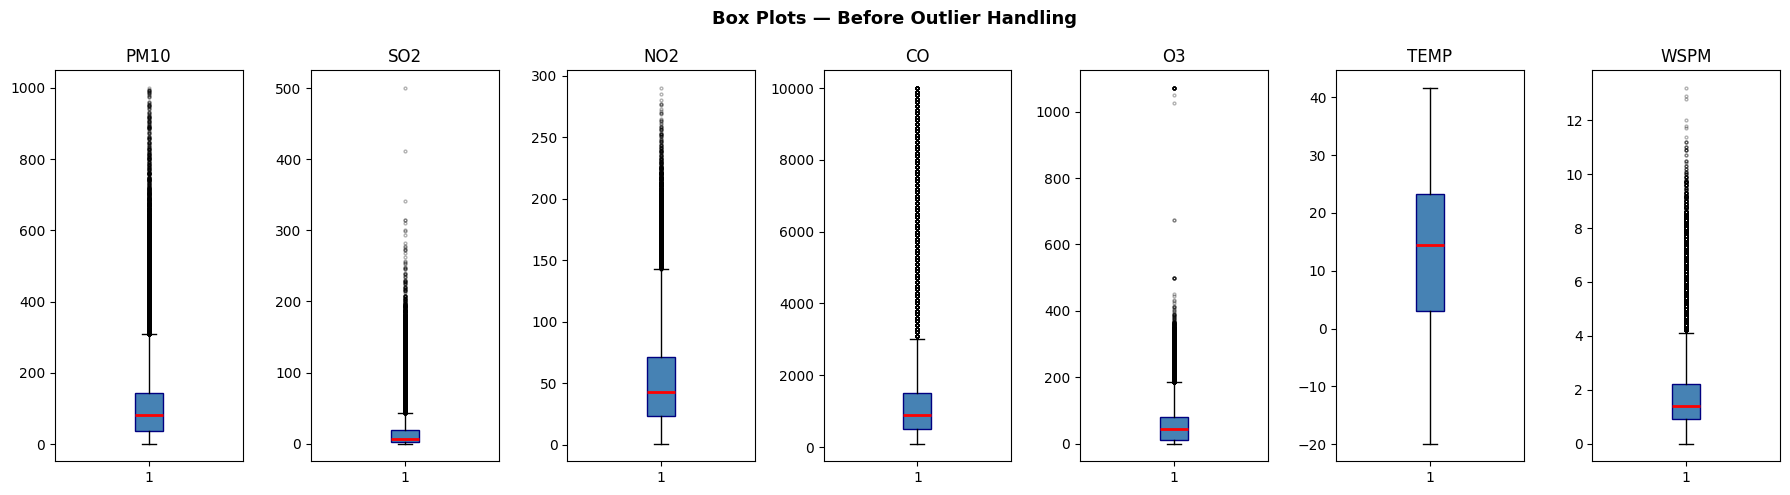

In [11]:
# ── CELL 7a: Box Plots Before Outlier Handling ──────────────────────────────
key_cols = ["PM10", "SO2", "NO2", "CO", "O3", "TEMP", "WSPM"]
key_cols = [c for c in key_cols if c in df_work.columns]

fig, axes = plt.subplots(1, len(key_cols), figsize=(18, 5))
for ax, col in zip(axes, key_cols):
    ax.boxplot(df_work[col].dropna(), patch_artist=True,
               boxprops=dict(facecolor="steelblue", color="navy"),
               medianprops=dict(color="red", linewidth=2),
               flierprops=dict(marker="o", color="orange", alpha=0.3, markersize=2))
    ax.set_title(col)

plt.suptitle("Box Plots — Before Outlier Handling", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

Cap Outliers

In [12]:
# ── CELL 7b: Outlier Capping (Winsorization) ────────────────────────────────
cols_to_cap = features + [target]

print("Capping outliers using IQR method:\n")
for col in cols_to_cap:
    Q1  = df_work[col].quantile(0.25)
    Q3  = df_work[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    before_min, before_max = df_work[col].min(), df_work[col].max()
    df_work[col] = df_work[col].clip(lower=lower, upper=upper)
    print(f"  {col:>6}: [{before_min:.2f} → {before_max:.2f}]  →  "
          f"[{df_work[col].min():.2f} → {df_work[col].max():.2f}]")

print(f"\n✅ Shape unchanged: {df_work.shape}")

Capping outliers using IQR method:

    PM10: [2.00 → 999.00]  →  [2.00 → 308.50]
     SO2: [0.29 → 500.00]  →  [0.29 → 43.00]
     NO2: [1.03 → 290.00]  →  [1.03 → 143.00]
      CO: [100.00 → 10000.00]  →  [100.00 → 3000.00]
      O3: [0.21 → 1071.00]  →  [0.21 → 186.00]
    TEMP: [-19.90 → 41.60]  →  [-19.90 → 41.60]
    PRES: [982.40 → 1042.80]  →  [982.40 → 1042.80]
    DEWP: [-43.40 → 29.10]  →  [-43.40 → 29.10]
    RAIN: [0.00 → 72.50]  →  [0.00 → 0.00]
    WSPM: [0.00 → 13.20]  →  [0.00 → 4.15]
   PM2.5: [2.00 → 999.00]  →  [2.00 → 247.50]

✅ Shape unchanged: (412029, 11)


 Box Plots After

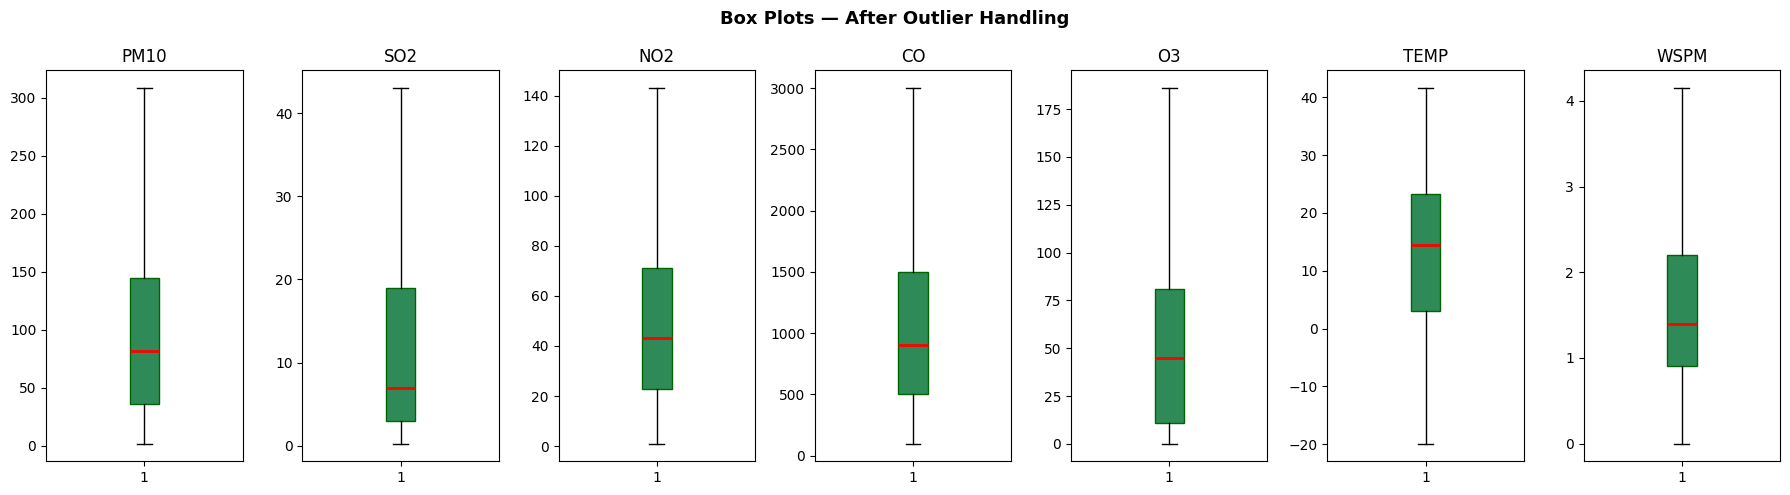

In [13]:
# ── CELL 7c: Box Plots After Outlier Handling ───────────────────────────────
fig, axes = plt.subplots(1, len(key_cols), figsize=(18, 5))
for ax, col in zip(axes, key_cols):
    ax.boxplot(df_work[col].dropna(), patch_artist=True,
               boxprops=dict(facecolor="seagreen", color="darkgreen"),
               medianprops=dict(color="red", linewidth=2),
               flierprops=dict(marker="o", color="orange", alpha=0.3, markersize=2))
    ax.set_title(col)

plt.suptitle("Box Plots — After Outlier Handling", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

Scatter: PM10 vs PM2.5

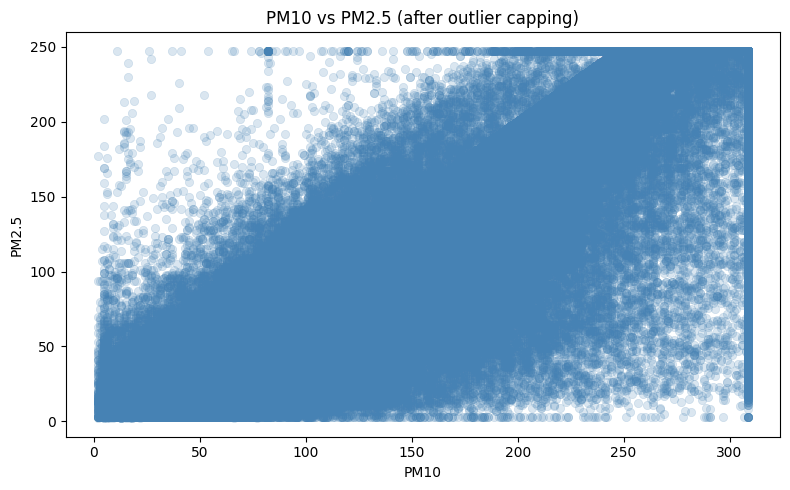

In [14]:
# ── CELL 7d: Scatter Plot — PM10 vs PM2.5 ───────────────────────────────────
plt.figure(figsize=(8, 5))
sns.scatterplot(x="PM10", y="PM2.5", data=df_work, alpha=0.2,
                color="steelblue", edgecolor=None)
plt.title("PM10 vs PM2.5 (after outlier capping)")
plt.xlabel("PM10")
plt.ylabel("PM2.5")
plt.tight_layout()
plt.show()

Rebuild X, y & Train/Test Split

In [15]:
# ── CELL 8: Rebuild X & y + Train/Test Split ────────────────────────────────
X = df_work[features].copy()
y = df_work[target].copy()

print(f"X shape : {X.shape}")
print(f"y shape : {y.shape}")
print(f"Nulls in X: {X.isnull().sum().sum()}")
print(f"Nulls in y: {y.isnull().sum()}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\n✅ Training samples : {len(X_train)}")
print(f"✅ Testing  samples : {len(X_test)}")

X shape : (412029, 10)
y shape : (412029,)
Nulls in X: 0
Nulls in y: 0

✅ Training samples : 329623
✅ Testing  samples : 82406


Evaluate Helper

In [16]:
# ── CELL 9: Evaluation Helper ───────────────────────────────────────────────
def model_summary(name, y_test, y_pred):
    mae  = mean_absolute_error(y_test, y_pred)
    mse  = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_test, y_pred)

    if r2 >= 0.90:   quality = "🟢 Excellent"
    elif r2 >= 0.75: quality = "🟡 Good"
    elif r2 >= 0.50: quality = "🟠 Moderate"
    else:            quality = "🔴 Poor"

    print(f"\n{'═'*40}")
    print(f"  Model : {name}")
    print(f"{'─'*40}")
    print(f"  MAE   : {mae:.4f}")
    print(f"  MSE   : {mse:.4f}")
    print(f"  RMSE  : {rmse:.4f}")
    print(f"  R²    : {r2:.4f}  {quality}")
    print(f"{'═'*40}")
    return {"Model": name, "MAE": mae, "MSE": mse, "RMSE": rmse, "R2": r2}

Linear Regression

In [17]:
# ── CELL 10: Linear Regression ──────────────────────────────────────────────
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

lr_scores = model_summary("Linear Regression", y_test, y_pred_lr)


════════════════════════════════════════
  Model : Linear Regression
────────────────────────────────────────
  MAE   : 18.1555
  MSE   : 662.3736
  RMSE  : 25.7366
  R²    : 0.8572  🟡 Good
════════════════════════════════════════


 Random Forest

In [18]:
# ── CELL 11: Random Forest ──────────────────────────────────────────────────
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

rf_scores = model_summary("Random Forest", y_test, y_pred_rf)


════════════════════════════════════════
  Model : Random Forest
────────────────────────────────────────
  MAE   : 11.2010
  MSE   : 319.1478
  RMSE  : 17.8647
  R²    : 0.9312  🟢 Excellent
════════════════════════════════════════


Actual vs Predicted

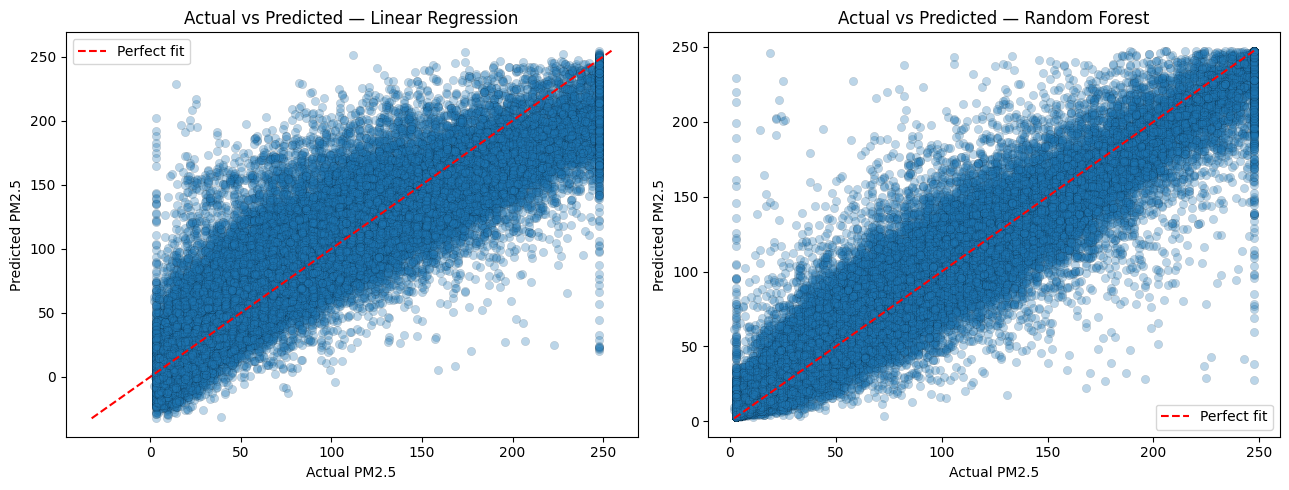

In [19]:
# ── CELL 12: Actual vs Predicted ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, y_pred, title in zip(
    axes,
    [y_pred_lr, y_pred_rf],
    ["Linear Regression", "Random Forest"]
):
    ax.scatter(y_test, y_pred, alpha=0.3, edgecolors="k", linewidths=0.2)
    lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
    ax.plot(lims, lims, "r--", linewidth=1.5, label="Perfect fit")
    ax.set_xlabel("Actual PM2.5")
    ax.set_ylabel("Predicted PM2.5")
    ax.set_title(f"Actual vs Predicted — {title}")
    ax.legend()

plt.tight_layout()
plt.show()

 Feature Importance

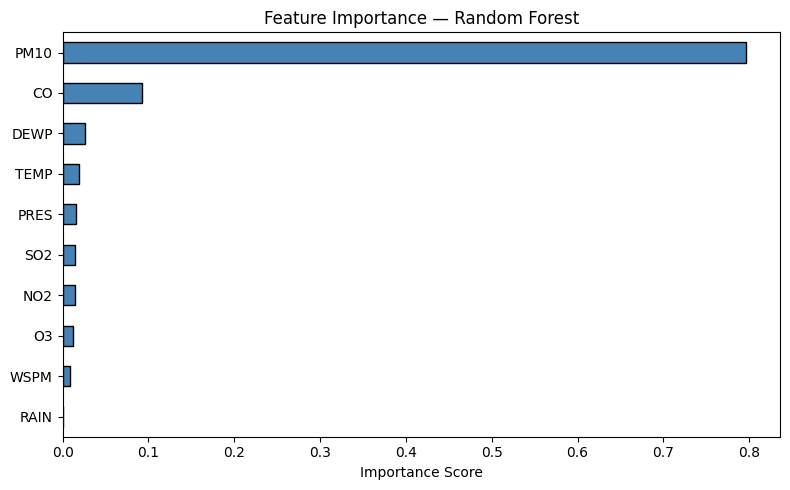

In [20]:
# ── CELL 13: Feature Importance ─────────────────────────────────────────────
importance = pd.Series(rf.feature_importances_, index=features).sort_values()

plt.figure(figsize=(8, 5))
importance.plot(kind="barh", color="steelblue", edgecolor="black")
plt.title("Feature Importance — Random Forest")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

Model Comparison

In [21]:
# ── CELL 14: Model Comparison ───────────────────────────────────────────────
from tabulate import tabulate

comparison = pd.DataFrame([lr_scores, rf_scores]).set_index("Model")
comparison = comparison.round(4)

print("\n📊 Model Comparison:\n")
print(tabulate(comparison, headers="keys", tablefmt="rounded_outline",
               numalign="center"))

best = max([lr_scores, rf_scores], key=lambda x: x["R2"])
print(f"\n🏆 Best Model: {best['Model']}  |  R² = {best['R2']:.4f}")


📊 Model Comparison:

╭───────────────────┬─────────┬─────────┬─────────┬────────╮
│ Model             │   MAE   │   MSE   │  RMSE   │   R2   │
├───────────────────┼─────────┼─────────┼─────────┼────────┤
│ Linear Regression │ 18.1555 │ 662.374 │ 25.7366 │ 0.8572 │
│ Random Forest     │ 11.201  │ 319.148 │ 17.8647 │ 0.9312 │
╰───────────────────┴─────────┴─────────┴─────────┴────────╯

🏆 Best Model: Random Forest  |  R² = 0.9312


Sample Prediction

In [22]:
# ── CELL 15: Sample Prediction ──────────────────────────────────────────────
from tabulate import tabulate

sample = pd.DataFrame({
    "PM10": [120.0, 250.0, 50.0],
    "SO2" : [10.0,  35.0,  5.0],
    "NO2" : [40.0,  80.0, 20.0],
    "CO"  : [800.0, 1500.0, 400.0],
    "O3"  : [60.0,  30.0,  90.0],
    "TEMP": [15.0,  5.0,   25.0],
    "PRES": [1010.0, 1015.0, 1005.0],
    "DEWP": [5.0,   -2.0,  15.0],
    "RAIN": [0.0,   0.0,   0.2],
    "WSPM": [2.0,   0.5,   4.0],
})

# Keep only features actually used
sample = sample[[f for f in features if f in sample.columns]]

pred_lr = lr.predict(sample)
pred_rf = rf.predict(sample)

results = sample.copy()
results["LR Pred"]  = pred_lr.round(2)
results["RF Pred"]  = pred_rf.round(2)
results["Diff"]     = (pred_rf - pred_lr).round(2)

print("📥 Sample Predictions — PM2.5:\n")
print(tabulate(results, headers="keys", tablefmt="rounded_outline",
               showindex=False, numalign="center"))

📥 Sample Predictions — PM2.5:

╭────────┬───────┬───────┬──────┬──────┬────────┬────────┬────────┬────────┬────────┬───────────┬───────────┬────────╮
│  PM10  │  SO2  │  NO2  │  CO  │  O3  │  TEMP  │  PRES  │  DEWP  │  RAIN  │  WSPM  │  LR Pred  │  RF Pred  │  Diff  │
├────────┼───────┼───────┼──────┼──────┼────────┼────────┼────────┼────────┼────────┼───────────┼───────────┼────────┤
│  120   │  10   │  40   │ 800  │  60  │   15   │  1010  │   5    │   0    │   2    │   80.5    │   83.95   │  3.45  │
│  250   │  35   │  80   │ 1500 │  30  │   5    │  1015  │   -2   │   0    │  0.5   │  173.15   │  198.83   │ 25.68  │
│   50   │   5   │  20   │ 400  │  90  │   25   │  1005  │   15   │  0.2   │   4    │   35.91   │   20.19   │ -15.72 │
╰────────┴───────┴───────┴──────┴──────┴────────┴────────┴────────┴────────┴────────┴───────────┴───────────┴────────╯


new



In [23]:
from xgboost import XGBRegressor

XGBoost Model

In [24]:
# ── CELL 16: Model 3 — XGBoost Regressor ────────────────────────────────────
# XGBoost (Extreme Gradient Boosting) builds trees sequentially —
# each new tree corrects the errors made by the previous one.
# It is one of the most powerful algorithms for tabular/structured data.
#
# Key parameters:
#   n_estimators   → number of trees to build (more = better but slower)
#   learning_rate  → how much each tree contributes (smaller = more careful)
#   max_depth      → how deep each tree grows (controls overfitting)
#   subsample      → fraction of rows used per tree (adds randomness)
#   colsample_bytree → fraction of features used per tree
#   n_jobs=-1      → use all CPU cores

from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators      = 300,
    learning_rate     = 0.05,
    max_depth         = 6,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    random_state      = 42,
    n_jobs            = -1,
    verbosity         = 0       # suppress training logs
)

xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

xgb_scores = model_summary("XGBoost", y_test, y_pred_xgb)


════════════════════════════════════════
  Model : XGBoost
────────────────────────────────────────
  MAE   : 12.6010
  MSE   : 372.3121
  RMSE  : 19.2954
  R²    : 0.9197  🟢 Excellent
════════════════════════════════════════


 Updated Actual vs Predicted

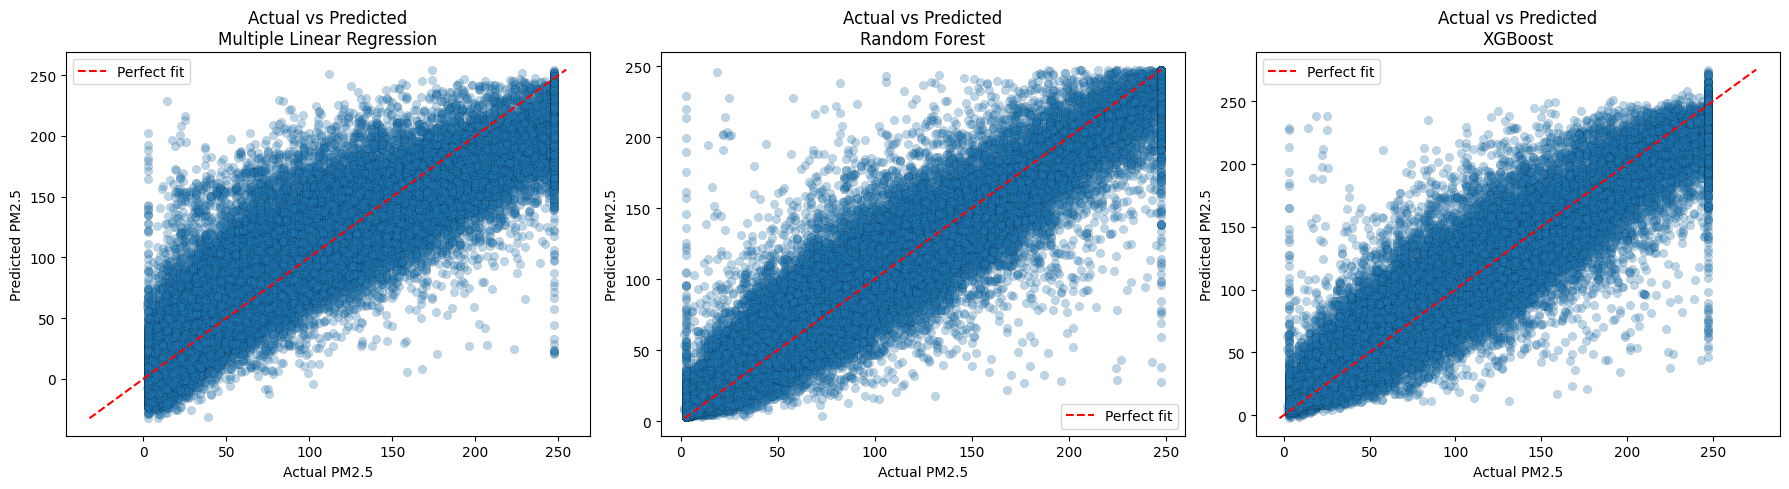

In [25]:
# ── CELL 17: Actual vs Predicted — All 3 Models ─────────────────────────────
# Side by side comparison of all three models.
# Dots closer to the red dashed line = better predictions.
# We expect XGBoost to hug the line most tightly.

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, y_pred, title in zip(
    axes,
    [y_pred_lr, y_pred_rf, y_pred_xgb],
    ["Multiple Linear Regression", "Random Forest", "XGBoost"]
):
    ax.scatter(y_test, y_pred, alpha=0.3, edgecolors="k", linewidths=0.2)
    lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
    ax.plot(lims, lims, "r--", linewidth=1.5, label="Perfect fit")
    ax.set_xlabel("Actual PM2.5")
    ax.set_ylabel("Predicted PM2.5")
    ax.set_title(f"Actual vs Predicted\n{title}")
    ax.legend()

plt.tight_layout()
plt.show()

Feature Importance XGBoost

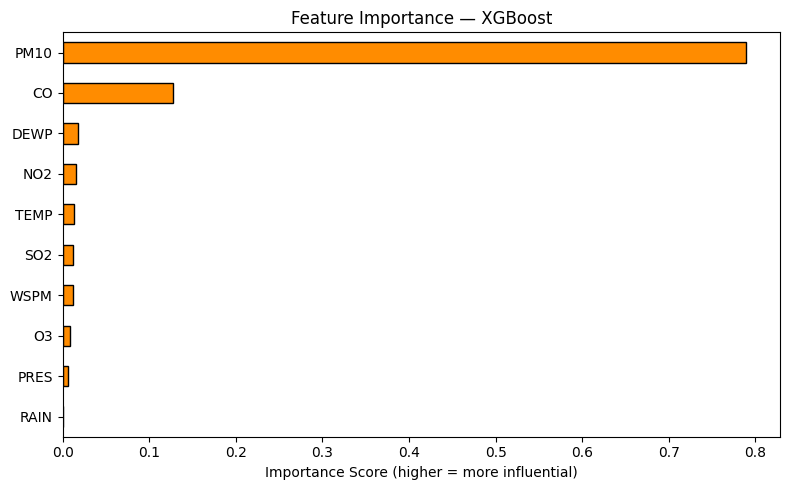

In [26]:
# ── CELL 18: Feature Importance — XGBoost ───────────────────────────────────
# XGBoost also provides feature importance scores.
# Comparing this with Random Forest importance (Cell 13) shows
# whether both models agree on which features matter most.
# If both agree → those features are genuinely the strongest predictors.

xgb_importance = pd.Series(
    xgb.feature_importances_, index=features
).sort_values()

plt.figure(figsize=(8, 5))
xgb_importance.plot(kind="barh", color="darkorange", edgecolor="black")
plt.title("Feature Importance — XGBoost")
plt.xlabel("Importance Score (higher = more influential)")
plt.tight_layout()
plt.show()

 Final Model Comparison

In [27]:
# ── CELL 19: Final Model Comparison — All 3 Models ──────────────────────────
# This is the final leaderboard comparing all three models.
# Best model = highest R² + lowest RMSE.
# XGBoost is expected to rank first, followed by Random Forest,
# then Multiple Linear Regression as the baseline.

from tabulate import tabulate

all_scores = [lr_scores, rf_scores, xgb_scores]
comparison = pd.DataFrame(all_scores).set_index("Model").round(4)

# Sort by R² descending — best model on top
comparison = comparison.sort_values("R2", ascending=False)

print("\n📊 Final Model Leaderboard:\n")
print(tabulate(comparison, headers="keys", tablefmt="rounded_outline",
               numalign="center"))

best = max(all_scores, key=lambda x: x["R2"])
print(f"\n🏆 Best Model : {best['Model']}")
print(f"   R²         : {best['R2']:.4f}")
print(f"   RMSE       : {best['RMSE']:.4f} μg/m³")


📊 Final Model Leaderboard:

╭───────────────────┬─────────┬─────────┬─────────┬────────╮
│ Model             │   MAE   │   MSE   │  RMSE   │   R2   │
├───────────────────┼─────────┼─────────┼─────────┼────────┤
│ Random Forest     │ 11.201  │ 319.148 │ 17.8647 │ 0.9312 │
│ XGBoost           │ 12.601  │ 372.312 │ 19.2954 │ 0.9197 │
│ Linear Regression │ 18.1555 │ 662.374 │ 25.7366 │ 0.8572 │
╰───────────────────┴─────────┴─────────┴─────────┴────────╯

🏆 Best Model : Random Forest
   R²         : 0.9312
   RMSE       : 17.8647 μg/m³


Sample Prediction all 3 models

In [28]:
# ── CELL 20: Sample Prediction — All 3 Models ───────────────────────────────
# Final demonstration — same 3 sample inputs predicted by all 3 models.
# This shows the practical output of the project end to end:
#   give pollution + weather readings → get PM2.5 prediction
#
# Sample 1 → moderate pollution
# Sample 2 → high pollution (high PM10, CO, low wind speed)
# Sample 3 → clean air (low pollutants, higher wind, light rain)

from tabulate import tabulate

sample = pd.DataFrame({
    "PM10": [120.0, 250.0,  50.0],
    "SO2" : [ 10.0,  35.0,   5.0],
    "NO2" : [ 40.0,  80.0,  20.0],
    "CO"  : [800.0, 1500.0, 400.0],
    "O3"  : [ 60.0,  30.0,  90.0],
    "TEMP": [ 15.0,   5.0,  25.0],
    "PRES": [1010.0, 1015.0, 1005.0],
    "DEWP": [  5.0,  -2.0,  15.0],
    "RAIN": [  0.0,   0.0,   0.2],
    "WSPM": [  2.0,   0.5,   4.0],
})

sample    = sample[[f for f in features if f in sample.columns]]
pred_lr   = lr.predict(sample)
pred_rf   = rf.predict(sample)
pred_xgb  = xgb.predict(sample)

results = pd.DataFrame({
    "PM10"    : sample["PM10"].values,
    "SO2"     : sample["SO2"].values,
    "NO2"     : sample["NO2"].values,
    "CO"      : sample["CO"].values,
    "WSPM"    : sample["WSPM"].values,
    "LR Pred" : pred_lr.round(2),
    "RF Pred" : pred_rf.round(2),
    "XGB Pred": pred_xgb.round(2),
})

print("📥 Sample Predictions — Predicted PM2.5 (μg/m³):\n")
print(tabulate(results, headers="keys", tablefmt="rounded_outline",
               showindex=False, numalign="center"))

📥 Sample Predictions — Predicted PM2.5 (μg/m³):

╭────────┬───────┬───────┬──────┬────────┬───────────┬───────────┬────────────╮
│  PM10  │  SO2  │  NO2  │  CO  │  WSPM  │  LR Pred  │  RF Pred  │  XGB Pred  │
├────────┼───────┼───────┼──────┼────────┼───────────┼───────────┼────────────┤
│  120   │  10   │  40   │ 800  │   2    │   80.5    │   83.95   │   78.48    │
│  250   │  35   │  80   │ 1500 │  0.5   │  173.15   │  198.83   │   186.7    │
│   50   │   5   │  20   │ 400  │   4    │   35.91   │   20.19   │   21.27    │
╰────────┴───────┴───────┴──────┴────────┴───────────┴───────────┴────────────╯


In [29]:
# ── CELL: Train Final RF on Full Data & Dump ────────────────────────────────
# Random Forest gave the best R² so we save it as our final model.
# We retrain on the FULL cleaned dataset (not just 80%) before saving.

import joblib

rf_final = RandomForestRegressor(
    n_estimators = 100,
    random_state = 42,
    n_jobs       = -1
)

rf_final.fit(X, y)    # full data — not X_train
print("✅ Final RF model trained on full dataset")
print(f"   Samples used : {len(X)}")

# Save the model
joblib.dump(rf_final, "pm25_rf_model.pkl")
print("✅ Model dumped — go to Files panel → right click pm25_rf_model.pkl → Download")

✅ Final RF model trained on full dataset
   Samples used : 412029
✅ Model dumped — go to Files panel → right click pm25_rf_model.pkl → Download


In [30]:
# ── CELL: Verify Dump ───────────────────────────────────────────────────────
# Load the saved file back and test one prediction
# to confirm the dump was successful.

rf_loaded = joblib.load("pm25_rf_model.pkl")

test_input = pd.DataFrame([{
    "PM10": 120.0, "SO2": 10.0,  "NO2": 40.0,
    "CO"  : 800.0, "O3" : 60.0,  "TEMP": 15.0,
    "PRES": 1010.0,"DEWP": 5.0,  "RAIN": 0.0,
    "WSPM": 2.0
}])

pred = rf_loaded.predict(test_input[features])[0]
print(f"✅ Verified — Predicted PM2.5 : {pred:.2f} μg/m³")
print("✅ Model is saved correctly and working")

✅ Verified — Predicted PM2.5 : 77.95 μg/m³
✅ Model is saved correctly and working
